# Step 4 - The NeuralProphet pipeline

This is one of four `step4_model_*` notebooks, one per model architecture. Read them after step 1 (data splitting), step 2 (cross-validation), and step 5 (hyperparameter tuning -- demoed on `prophet_xgb`). Step 5 shows *where* a final set of hyperparameters comes from; here we fit the model with the package defaults from `params.yaml` and inspect its behavior. To run this notebook with tuned parameters instead, pass `config_overrides={"models": {"neuralprophet": best_params}}` into `run_single_its()`.

**Goal:** walk through `run_single_its()` using the `NeuralProphetModel`.

Sections:
- **4a.** Load the pre-built dummy data.
- **4b.** Fit `NeuralProphetModel` manually and inspect the `FitResult`.
- **4c.** Inside NeuralProphet -- AR terms and the warmup period.
- **4d.** Run the full pipeline via `run_single_its()`.
- **4e.** Inspect `PipelineResult`: metrics, excess table, ATE.
- **4f.** Reproduce the counterfactual plot with annotations.

In [1]:
%matplotlib inline

from IPython.display import display
import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(name)s - %(message)s",
    datefmt="%H:%M:%S",
)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("its2s").setLevel(logging.WARNING)
logging.getLogger("NP").setLevel(logging.CRITICAL)

OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(exist_ok=True)
INTERVENTION = "2022-03-15"
TEST_DAYS    = 365
HOLDOUT_DAYS = 42

## 4a. Load the pre-built dummy data

The series has a +8/day intervention effect baked in for 42 days after 2022-03-15.

In [2]:
df = pd.read_csv("data/dummy_data.csv", parse_dates=["ds"])

print("=" * 60)
print("Dummy dataset (with +8/day intervention effect)")
print("=" * 60)
print(df.tail())

Dummy dataset (with +8/day intervention effect)
             ds          y  covar_linear  covar_dow  covar_noise
1571 2022-04-21  71.975041      0.995182        3.0    -0.356611
1572 2022-04-22  73.042307      1.033630        4.0     0.247103
1573 2022-04-23  72.275013      1.003513        5.0     1.129482
1574 2022-04-24  69.332534      1.004775        6.0    -0.321536
1575 2022-04-25  69.651058      0.981820        0.0    -1.057655


## 4b. Manual fit

This replicates what `run_single_its` does internally, so we can inspect the `FitResult`.

NeuralProphet trains a neural network, so this cell takes longer than ARIMA or Prophet-based models.

In [3]:
from its2s.data_prep import prepare_splits
from its2s.models.neuralprophet import NeuralProphetModel
from its2s.settings import get_model_config, load_config

config = load_config()
splits = prepare_splits(df, INTERVENTION, test_days=TEST_DAYS, holdout_days=HOLDOUT_DAYS)

model_params = get_model_config(config, "neuralprophet")
model = NeuralProphetModel(params=model_params)

print("Fitting NeuralProphetModel on training data ...")
print(f"  Training rows : {len(splits.train_df)}")
print(f"  Training range: {splits.train_df['ds'].min().date()} -> {splits.train_df['ds'].max().date()}")
print(f"  n_lags        : {model_params.get('n_lags', 14)}")
print(f"  epochs        : {model_params.get('epochs', 100)}")

fit_result = model.fit(splits.train_df, target_col="y", date_col="ds")

n_nan = int(np.isnan(fit_result.fitted_values).sum())
n_lags = model_params.get("n_lags", 14)
print("\nFitResult fields:")
print(f"  fitted_values  shape = {fit_result.fitted_values.shape}")
print(f"  residuals      shape = {fit_result.residuals.shape}")
print(f"  NaN fitted values   = {n_nan}  (AR warmup = n_lags = {n_lags})")
print(f"  residuals  mean={np.nanmean(fit_result.residuals):.4f}  std={np.nanstd(fit_result.residuals):.4f}  (NaNs excluded)")

Fitting NeuralProphetModel on training data ...
  Training rows : 1227
  Training range: 2018-01-01 -> 2021-05-11
  n_lags        : 14
  epochs        : 100


Training: 0it [00:00, ?it/s]

Predicting: 19it [00:00, ?it/s]


FitResult fields:
  fitted_values  shape = (1227,)
  residuals      shape = (1227,)
  NaN fitted values   = 14  (AR warmup = n_lags = 14)
  residuals  mean=0.0244  std=2.3681  (NaNs excluded)


## 4c. Inside NeuralProphet -- AR terms and the warmup period

NeuralProphet uses autoregressive (AR) lags: to predict day `t`, it uses the observed values
at days `t-1` through `t-n_lags`. This means the first `n_lags` rows cannot produce a
prediction because there is no history yet -- they form the **AR warmup period** and produce
NaN fitted values and residuals.

This has a practical implication for Moving Block Bootstrap: the bootstrap resamples
only the non-NaN residuals. The available residuals are `total_train_rows - n_lags`.

In [4]:
final_metrics = fit_result.metadata.get("final_metrics")
if final_metrics is not None:
    print("Training loss (last 5 epochs):")
    print(final_metrics.tail().to_string(index=False))

n_lags       = model_params.get("n_lags", 14)
n_train      = len(splits.train_df)
n_valid_resid = int(np.isfinite(fit_result.residuals).sum())
print(f"\n  Total training rows      : {n_train}")
print(f"  AR warmup rows (n_lags)  : {n_lags}")
print(f"  Valid (non-NaN) residuals: {n_valid_resid}")
print(f"  -> MBB will resample from {n_valid_resid} residuals")

Training loss (last 5 epochs):
     MAE     RMSE     Loss  RegLoss  epoch
1.902739 2.358850 0.009853      0.0     95
1.902454 2.363466 0.009854      0.0     96
1.901963 2.359499 0.009847      0.0     97
1.902673 2.360817 0.009859      0.0     98
1.901860 2.362189 0.009843      0.0     99

  Total training rows      : 1227
  AR warmup rows (n_lags)  : 14
  Valid (non-NaN) residuals: 1213
  -> MBB will resample from 1213 residuals


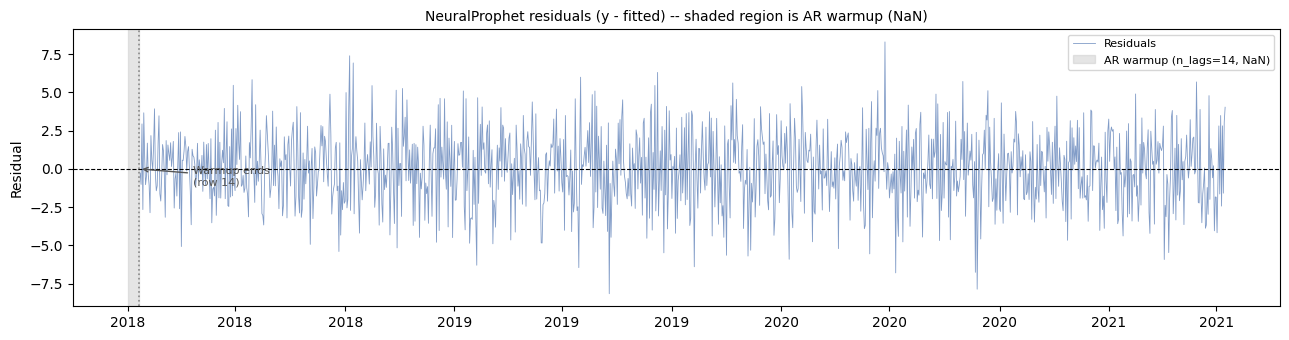

In [5]:
dates    = splits.train_df["ds"].values
residuals = fit_result.residuals
warmup_end = splits.train_df["ds"].iloc[n_lags - 1]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates, residuals, linewidth=0.6, color="#4C72B0", alpha=0.7, label="Residuals")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Shade the warmup region
ax.axvspan(dates[0], warmup_end, color="#CCCCCC", alpha=0.5, label=f"AR warmup (n_lags={n_lags}, NaN)")
ax.axvline(pd.Timestamp(warmup_end), color="#888888", linestyle=":", linewidth=1.2)
ax.annotate(
    f"Warmup ends\n(row {n_lags})",
    xy=(pd.Timestamp(warmup_end), 0),
    xytext=(pd.Timestamp(warmup_end) + pd.Timedelta(days=60), residuals[n_lags + 10]),
    arrowprops=dict(arrowstyle="->", color="#555555"),
    fontsize=8,
    color="#555555",
)

ax.set_title("NeuralProphet residuals (y - fitted) -- shaded region is AR warmup (NaN)", fontsize=10)
ax.set_ylabel("Residual")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "neuralprophet_residuals.png", dpi=150)
display(fig)

## 4d. Full pipeline run

MBB bootstrap runs with `n_sim=100` for speed; production use should set this to 1000+.
Expect this cell to take longer than ARIMA or Prophet models due to neural network training.

In [6]:
from its2s import run_single_its

result = run_single_its(
    df=df,
    intervention_date=INTERVENTION,
    model_name="neuralprophet",
    config_overrides={
        "bootstrap": {"n_sim": 100},
        "periods":   {"test_days": TEST_DAYS, "holdout_days": HOLDOUT_DAYS},
    },
    output_dir=OUT_DIR,
    seed=42,
)

print("PipelineResult fields:")
print(f"  model_name       : {result.model_name}")
print(f"  fit_result       : FitResult with {len(result.fit_result.fitted_values)} fitted values")
print(f"  bootstrap_result : BootstrapCIResult  pred_matrix shape = {result.bootstrap_result.pred_matrix.shape}")
print(f"  n_successful sims: {result.bootstrap_result.n_successful}")
print(f"  metrics_train    : {result.metrics_train}")
print(f"  metrics_test     : {result.metrics_test}")

Training: 0it [00:00, ?it/s]

Predicting: 19it [00:00, ?it/s]

12:19:27  WARNING  its2s.diagnostics - Ljung-Box test (p=0.0000) suggests significant residual autocorrelation for model 'neuralprophet'. Bootstrap CIs may undercover.


Predicting: 19it [00:00, ?it/s]

Predicting: 19it [00:00, ?it/s]

PipelineResult fields:
  model_name       : neuralprophet
  fit_result       : FitResult with 1227 fitted values
  bootstrap_result : BootstrapCIResult  pred_matrix shape = (349, 100)
  n_successful sims: 0
  metrics_train    : MetricsResult(rmse=2.3036615618128518, mae=1.8237677053085555, mape=3.553473219858257, smape=3.504400197410357, mase=None, r2=0.9040187505835086)
  metrics_test     : MetricsResult(rmse=2.4956253306117557, mae=1.9883849766189923, mape=3.8955142864738725, smape=3.6981501348730337, mase=0.8609906062304502, r2=0.862155054616512)


## 4e. Metrics and excess table

In [7]:
metrics_df = pd.DataFrame({
    "RMSE":  [result.metrics_train.rmse,  result.metrics_test.rmse],
    "MAE":   [result.metrics_train.mae,   result.metrics_test.mae],
    "MAPE":  [result.metrics_train.mape,  result.metrics_test.mape],
    "SMAPE": [result.metrics_train.smape, result.metrics_test.smape],
    "R2":    [result.metrics_train.r2,    result.metrics_test.r2],
}, index=["Train", "Test"])
print(metrics_df.round(3).to_string())

        RMSE    MAE   MAPE  SMAPE     R2
Train  2.304  1.824  3.553  3.504  0.904
Test   2.496  1.988  3.896  3.698  0.862


In [8]:
print("Period-level excess:")
print(result.excess_table.period_excess.to_string(index=False))
print("\nDaily excess - first 10 holdout days:")
print(result.excess_table.obs_excess.head(10).to_string(index=False))

Period-level excess:
      period start_date   end_date  n_days  total_observed  total_expected  total_excess  excess_ci_lo  excess_ci_hi  excess_pct
Full holdout 2022-03-15 2022-04-25      42     3029.800778     2988.127441     41.673337   3029.800778   3029.800778     1.39463

Daily excess - first 10 holdout days:
      date  observed  expected  expected_ci_lo  expected_ci_hi    excess  excess_ci_lo  excess_ci_hi  excess_pct  excess_pct_ci_lo  excess_pct_ci_hi
2022-03-15 76.449700 64.115265             NaN             NaN 12.334435           NaN           NaN   19.237908               NaN               NaN
2022-03-16 70.565458 63.172264             NaN             NaN  7.393194           NaN           NaN   11.703228               NaN               NaN
2022-03-17 74.032036 66.500984             NaN             NaN  7.531052           NaN           NaN   11.324722               NaN               NaN
2022-03-18 69.205309 67.375183             NaN             NaN  1.830126           NaN

**Note — NaN confidence intervals (known limitation).** All CI columns (`expected_ci_lo`, `expected_ci_hi`, `excess_ci_lo`, `excess_ci_hi`) are NaN because all 100 bootstrap simulations failed (`n_successful = 0` above). The root cause is NeuralProphet's AR warmup: the first `n_lags` rows of `fit_result.fitted_values` are NaN, and Moving Block Bootstrap builds the perturbed training series as `fitted_values + resampled_residuals` — leaving those rows as NaN. NeuralProphet cannot refit on a training series with NaN target values, so every simulation errors out. This is a known incompatibility between NeuralProphet and the current MBB implementation; a fix is tracked in a separate issue.

In [9]:
from its2s.metrics.excess import calc_ate_summary

ate = calc_ate_summary(result.excess_table.obs_excess)
print("Average Treatment Effect (ATE) summary:")
print(ate.to_string(index=False))
print("\n  Total ATE      = sum of daily excess over full holdout")
print("  Mean ATE per obs = average excess per observation")
print(f"  Simulated effect was +8/day for {HOLDOUT_DAYS} days -> expected total excess ~{8 * HOLDOUT_DAYS}")

Average Treatment Effect (ATE) summary:
        metric  estimate  ci_lo  ci_hi  n_days
     Total ATE 41.673115    0.0    0.0      42
Mean Daily ATE  0.992217    0.0    0.0      42

  Total ATE      = sum of daily excess over full holdout
  Mean Daily ATE = average excess per day
  Simulated effect was +8/day for 42 days -> expected total excess ~336


## 4f. Counterfactual plot (annotated)

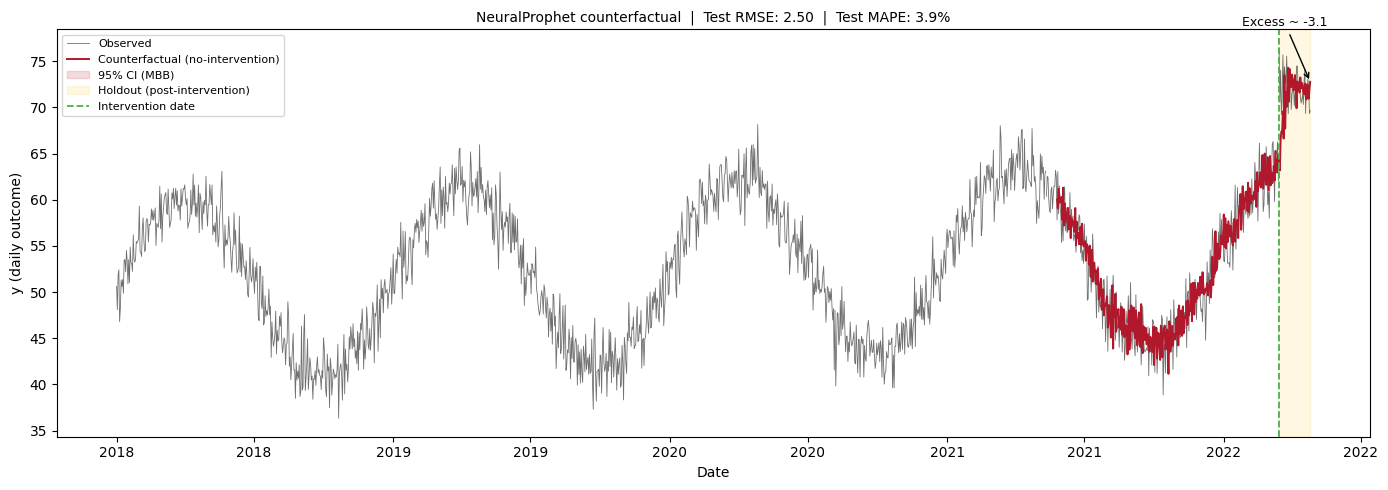

In [10]:
br = result.bootstrap_result
pred_dates = pd.to_datetime(br.dates)
intervention_ts = pd.Timestamp(INTERVENTION)

fig, ax = plt.subplots(figsize=(14, 5))

for part in [splits.train_df, splits.test_df, splits.holdout_df]:
    ax.plot(part["ds"], part["y"], color="#333333", linewidth=0.6, alpha=0.7)
ax.plot([], [], color="#333333", linewidth=0.6, alpha=0.7, label="Observed")

ax.plot(pred_dates, br.predicted, color="#B2182B", linewidth=1.4,
        label="Counterfactual (no-intervention)")
ax.fill_between(pred_dates, br.conf_lo, br.conf_hi,
                color="#B2182B", alpha=0.15, label="95% CI (MBB)")

ax.axvspan(intervention_ts, splits.holdout_df["ds"].max(),
           color="#FEE08B", alpha=0.25, label="Holdout (post-intervention)")
ax.axvline(intervention_ts, color="#4DAF4A", linestyle="--", linewidth=1.3,
           label="Intervention date")

last_date = pred_dates[pred_dates >= intervention_ts][-1]
last_obs  = splits.holdout_df.loc[splits.holdout_df["ds"] == last_date, "y"].values
last_pred = br.predicted[pred_dates == last_date]
if len(last_obs) and len(last_pred):
    ax.annotate(
        f"Excess ~ {float(last_obs[0] - last_pred[0]):.1f}",
        xy=(last_date, float(last_pred[0])),
        xytext=(last_date - pd.Timedelta(days=90), float(last_pred[0]) + 6),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=9,
    )

ax.set_xlabel("Date")
ax.set_ylabel("y (daily outcome)")
ax.set_title(
    f"NeuralProphet counterfactual  |  Test RMSE: {result.metrics_test.rmse:.2f}"
    f"  |  Test MAPE: {result.metrics_test.mape:.1f}%",
    fontsize=10,
)
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "neuralprophet_counterfactual.png", dpi=150)
display(fig)

## Key takeaways

1. `NeuralProphetModel.fit()` trains a neural network with `n_lags` autoregressive terms and optional lagged regressors. Training is slower than statistical or tree-based models.
2. The AR warmup period: the first `n_lags` rows cannot produce a fitted value because there is no preceding history. These rows yield NaN in `fit_result.fitted_values` and `fit_result.residuals`.
3. Moving Block Bootstrap resamples only the non-NaN residuals. The effective residual pool is `n_train_rows - n_lags`.
4. `run_single_its()` orchestrates: `load_config -> prepare_splits -> fit -> bootstrap -> metrics -> excess -> save`.
5. Excess = observed - counterfactual_predicted. With a true +8/day effect over 42 days, total excess should land near 336 (noise aside).